In [1]:
from pathlib import Path

import xarray as xr
import matplotlib.pyplot as plt

In [2]:
data_path = Path("outputs_lite")
ndvi_cube_path = data_path / "efast_ndvi.nc"

In [5]:
ndvi_da = xr.open_dataset(ndvi_cube_path, chunks="auto")["ndvi"]
image_da = ndvi_da.isel(t=0, y=slice(10, None, None))
h, w = image_da.shape

dpi = 300
image_path = Path("img/thumbnail.png")
imshow_args = dict(cmap="RdYlGn", vmin=-1, vmax=1, interpolation="bilinear")

fig = plt.figure(figsize=(w / dpi, h / dpi), dpi=dpi)
ax = fig.add_axes([0, 0, 1, 1])


ax.imshow(image_da.values, **imshow_args)
fig.savefig(image_path, dpi=dpi)
plt.close(fig)

(np.float64(-0.5), np.float64(2147.5), np.float64(2211.5), np.float64(-0.5))

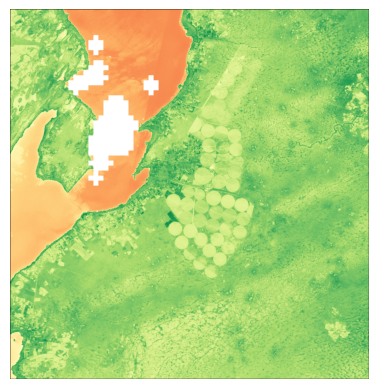

In [6]:
img = plt.imread(image_path)
plt.imshow(img)
plt.axis("off")